# Benchmark DirectLiNGAM CPU vs GPU execution time.

In [1]:
import gc
import time
import traceback
from dataclasses import dataclass
from typing import Dict, List, Optional

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from lingam import DirectLiNGAM

## Configuration

In [2]:
VARIABLE_COUNTS = [10, 20, 50, 100, 200]
N_SAMPLE_COUNTS = [1000, 2000, 5000, 10000]
EDGE_PROB = 0.10
COEF_LOW = 0.3
COEF_HIGH = 1.0

N_REPEATS = 1
RANDOM_SEED = 42

## Functions

In [ ]:
def generate_random_lingam_data(
    n_samples: int,
    n_features: int,
    edge_prob: float = 0.10,
    coef_low: float = 0.3,
    coef_high: float = 1.0,
    random_state: Optional[int] = None,
):
    rng = np.random.default_rng(random_state)

    B_true = np.zeros((n_features, n_features), dtype=np.float64)

    for to_idx in range(n_features):
        for from_idx in range(to_idx):
            if rng.random() < edge_prob:
                sign = rng.choice([-1.0, 1.0])
                coef = rng.uniform(coef_low, coef_high)
                B_true[to_idx, from_idx] = sign * coef

    # Non-Gaussian independent noise
    E = rng.laplace(loc=0.0, scale=1.0, size=(n_samples, n_features))

    # x = B x + e
    # x = inv(I - B) e
    # For row-wise samples:
    # X = E @ inv(I - B).T
    I = np.eye(n_features)
    mixing = np.linalg.inv(I - B_true)
    X = E @ mixing.T

    # Standardize for numerical stability
    X = X - X.mean(axis=0, keepdims=True)
    X = X / X.std(axis=0, keepdims=True)

    return X, B_true


# ============================================================
# Benchmark utilities
# ============================================================

@dataclass
class BenchmarkResult:
    n_features: int
    n_samples: int
    backend: str
    measure: str
    adaptive_lasso: bool
    label: str
    repeat: int
    elapsed_sec: Optional[float]
    status: str
    error: Optional[str]


def benchmark_one_fit(
    X: np.ndarray,
    measure: str,
    adaptive_lasso: bool,
    random_state: int,
):
    """
    Measure fit time of DirectLiNGAM for one run.
    """
    model = DirectLiNGAM(
        random_state=random_state,
        measure=measure,
        adaptive_lasso=adaptive_lasso,
    )

    start = time.perf_counter()
    model.fit(X)
    end = time.perf_counter()

    elapsed_sec = end - start
    return elapsed_sec, model


def run_benchmark(
    variable_counts: List[int],
    n_samples_list: List[int],
    n_repeats: int,
    random_seed: int,
) -> pd.DataFrame:
    """
    Run CPU and GPU benchmark over multiple variable counts and sample counts.
    """
    results: List[BenchmarkResult] = []

    benchmark_targets = [
        {
            "backend": "CPU",
            "measure": "pwling",
            "adaptive_lasso": True,
            "label": "CPU (AdaLasso)",
        },
        {
            "backend": "CPU",
            "measure": "pwling",
            "adaptive_lasso": False,
            "label": "CPU (no AdaLasso)",
        },
        {
            "backend": "GPU",
            "measure": "pwling_fast",
            "adaptive_lasso": True,
            "label": "GPU (AdaLasso)",
        },
        {
            "backend": "GPU",
            "measure": "pwling_fast",
            "adaptive_lasso": False,
            "label": "GPU (no AdaLasso)",
        },
    ]


    # Warm-up run for GPU
    X, _ = generate_random_lingam_data(
        n_samples=100,
        n_features=10,
        edge_prob=EDGE_PROB,
        coef_low=COEF_LOW,
        coef_high=COEF_HIGH,
        random_state=123,
    )
    _, _ = benchmark_one_fit(
        X=X,
        measure="pwling_fast",
        adaptive_lasso=False,
        random_state=123,
    )


    for n_features in variable_counts:
        for n_samples in n_samples_list:
            print("=" * 80)
            print(f"Generating data: n_samples={n_samples}, n_features={n_features}")

            X, B_true = generate_random_lingam_data(
                n_samples=n_samples,
                n_features=n_features,
                edge_prob=EDGE_PROB,
                coef_low=COEF_LOW,
                coef_high=COEF_HIGH,
                random_state=random_seed + n_features + n_samples,
            )

            for target in benchmark_targets:
                backend = target["backend"]
                measure = target["measure"]
                adaptive_lasso = target["adaptive_lasso"]
                label = target["label"]

                print("-" * 80)
                print(f"Benchmark: label={label}, n_features={n_features}, n_samples={n_samples}")

                for repeat in range(1, n_repeats + 1):
                    print(f"Run {repeat}/{n_repeats}...")

                    try:
                        elapsed_sec, model = benchmark_one_fit(
                            X=X,
                            measure=measure,
                            adaptive_lasso=adaptive_lasso,
                            random_state=random_seed + repeat,
                        )

                        print(f"Elapsed time: {elapsed_sec:.4f} sec")

                        results.append(
                            BenchmarkResult(
                                n_features=n_features,
                                n_samples=n_samples,
                                backend=backend,
                                measure=measure,
                                adaptive_lasso=adaptive_lasso,
                                label=label,
                                repeat=repeat,
                                elapsed_sec=elapsed_sec,
                                status="ok",
                                error=None,
                            )
                        )

                    except Exception as e:
                        err_msg = traceback.format_exc()
                        print(f"Failed: label={label}, n_features={n_features}, n_samples={n_samples}, repeat={repeat}")
                        print(err_msg)

                        results.append(
                            BenchmarkResult(
                                n_features=n_features,
                                n_samples=n_samples,
                                backend=backend,
                                measure=measure,
                                adaptive_lasso=adaptive_lasso,
                                label=label,
                                repeat=repeat,
                                elapsed_sec=None,
                                status="failed",
                                error=str(e),
                            )
                        )

                    gc.collect()

    df = pd.DataFrame([r.__dict__ for r in results])
    return df


# ============================================================
# Summary utilities
# ============================================================

def summarize_results(df: pd.DataFrame) -> pd.DataFrame:
    """
    Summarize benchmark results by variable count and backend.
    """
    ok_df = df[df["status"] == "ok"].copy()

    summary = (
        ok_df
        .groupby(["n_features", "n_samples", "backend", "measure", "adaptive_lasso", "label"], as_index=False)
        .agg(
            elapsed_mean_sec=("elapsed_sec", "mean"),
            elapsed_std_sec=("elapsed_sec", "std"),
            elapsed_min_sec=("elapsed_sec", "min"),
            elapsed_max_sec=("elapsed_sec", "max"),
            n_success=("elapsed_sec", "count"),
        )
    )

    return summary


def add_speedup(summary: pd.DataFrame) -> pd.DataFrame:
    """
    Add GPU speedup relative to CPU, computed separately for each adaptive_lasso setting.

    speedup = CPU mean time / GPU mean time
    """
    pivot = summary.pivot_table(
        index=["n_features", "n_samples", "adaptive_lasso"],
        columns="backend",
        values="elapsed_mean_sec",
        aggfunc="first",
    ).reset_index()

    if "CPU" in pivot.columns and "GPU" in pivot.columns:
        pivot["gpu_speedup_vs_cpu"] = pivot["CPU"] / pivot["GPU"]
    else:
        pivot["gpu_speedup_vs_cpu"] = np.nan

    summary_with_speedup = summary.merge(
        pivot[["n_features", "n_samples", "adaptive_lasso", "gpu_speedup_vs_cpu"]],
        on=["n_features", "n_samples", "adaptive_lasso"],
        how="left",
    )

    return summary_with_speedup


def plot_benchmark_results(summary_df: pd.DataFrame):
    series_styles = [
        ("CPU (AdaLasso)", "o", "tab:blue", "-"),
        ("CPU (no AdaLasso)", "o", "tab:blue", "--"),
        ("GPU (AdaLasso)", "s", "tab:orange", "-"),
        ("GPU (no AdaLasso)", "s", "tab:orange", "--"),
    ]

    for n_features in sorted(summary_df["n_features"].unique()):
        fig, ax = plt.subplots(figsize=(8, 4))

        df_n = summary_df[summary_df["n_features"] == n_features]

        for label, marker, color, linestyle in series_styles:
            sub = (
                df_n[df_n["label"] == label]
                .sort_values("n_samples")
            )

            if sub.empty:
                continue

            ax.plot(
                sub["n_samples"],
                sub["elapsed_mean_sec"],
                marker=marker,
                color=color,
                linestyle=linestyle,
                linewidth=1,
                label=label,
            )

            ax.fill_between(
                sub["n_samples"],
                sub["elapsed_mean_sec"] - sub["elapsed_std_sec"].fillna(0),
                sub["elapsed_mean_sec"] + sub["elapsed_std_sec"].fillna(0),
                alpha=0.15,
                color=color,
            )

        ax.set_xlabel("Number of Samples")
        ax.set_ylabel("Execution Time [sec]")
        ax.set_title(f"DirectLiNGAM CPU vs GPU x AdaptiveLasso Benchmark (n_features={n_features})")

        ax.grid(True, which="both", linestyle="--", alpha=0.5)
        ax.legend()

        plt.tight_layout()
        plt.show()

## DirectLiNGAM CPU vs GPU benchmark

In [ ]:
print(f"Variable counts: {VARIABLE_COUNTS}")
print(f"Sample counts: {N_SAMPLE_COUNTS}")
print(f"n_repeats: {N_REPEATS}")

df_results = run_benchmark(
    variable_counts=VARIABLE_COUNTS,
    n_samples_list=N_SAMPLE_COUNTS,
    n_repeats=N_REPEATS,
    random_seed=RANDOM_SEED,
)

df_summary = summarize_results(df_results)
df_summary = add_speedup(df_summary)

Variable counts: [10, 20, 50, 100, 200]
Sample counts: [1000, 2000, 5000, 10000]
n_repeats: 1
Generating data: n_samples=1000, n_features=10
--------------------------------------------------------------------------------
Benchmark: label=CPU (AdaLasso), n_features=10, n_samples=1000
Run 1/1...
Elapsed time: 0.1793 sec
--------------------------------------------------------------------------------
Benchmark: label=CPU (no AdaLasso), n_features=10, n_samples=1000
Run 1/1...
Elapsed time: 0.1679 sec
--------------------------------------------------------------------------------
Benchmark: label=GPU (AdaLasso), n_features=10, n_samples=1000
Run 1/1...
Elapsed time: 0.1427 sec
--------------------------------------------------------------------------------
Benchmark: label=GPU (no AdaLasso), n_features=10, n_samples=1000
Run 1/1...
Elapsed time: 0.1119 sec
Generating data: n_samples=2000, n_features=10
--------------------------------------------------------------------------------
Bench

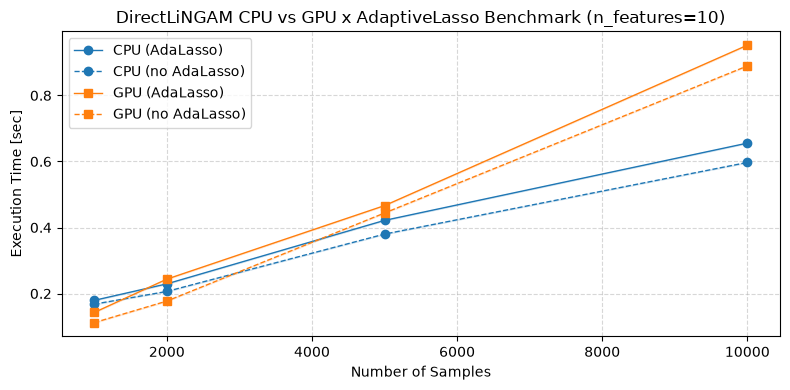

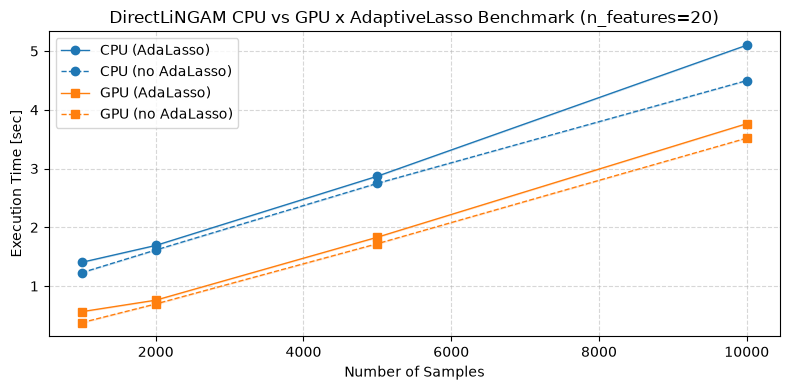

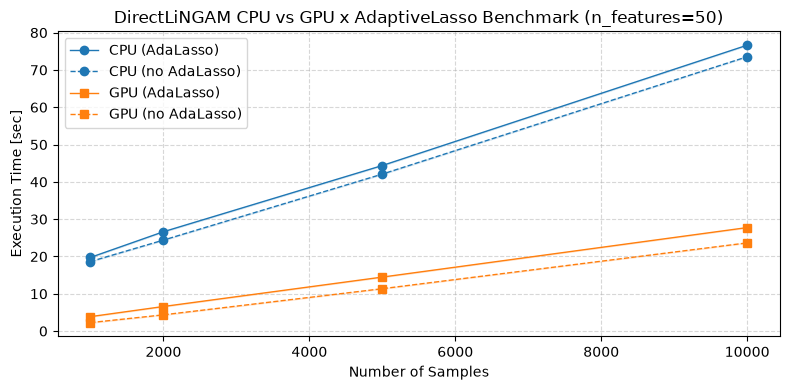

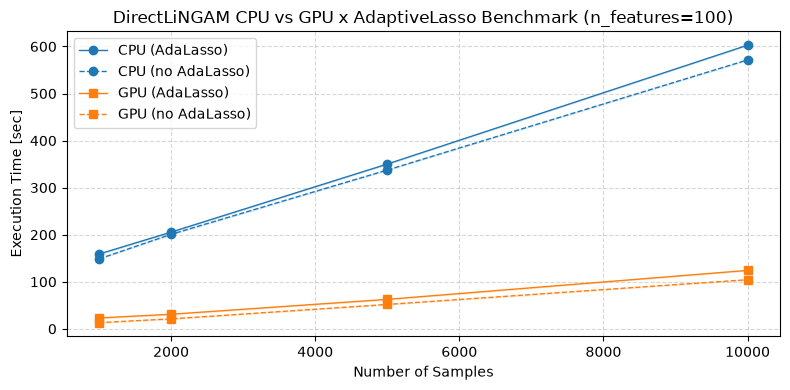

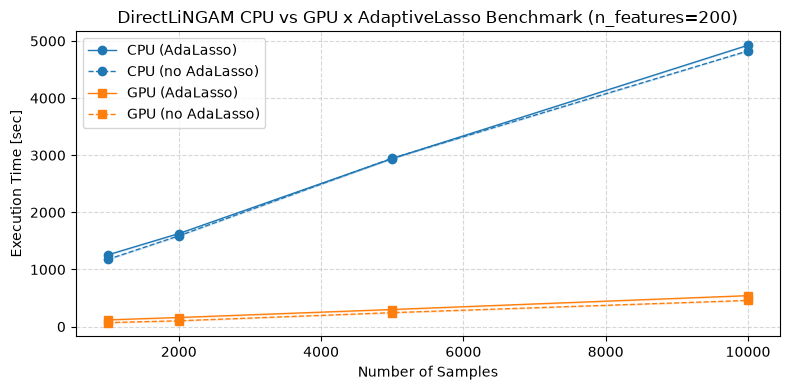

In [5]:
plot_benchmark_results(df_summary)